<a href="https://colab.research.google.com/github/hamnasz/DevByte/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning — Regression
**DevByte AI/ML Internship — BETA Project**

**Assigned:** 2026-06-30 &nbsp;|&nbsp; **Due:** 2026-07-21

### What this notebook does
Trains regression models to predict house prices and validates them using R-squared and other metrics.

### Models covered
| Model | Purpose |
|---|---|
| Linear Regression | Baseline predictor |
| Ridge Regression | Linear + L2 regularization (reduces overfitting) |
| Lasso Regression | Linear + L1 regularization (also drops weak features) |
| Logistic Regression | Bonus: classifies houses as High or Low value |

---
## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, classification_report, confusion_matrix
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

SEED = 42
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Step 2: Generate the Housing Dataset

We build a realistic synthetic dataset of 1,000 houses. Each house has 9 features that affect its price. The target column is `price_lakh_pkr` (house price in PKR Lakh).

In [2]:
np.random.seed(SEED)
n = 1000

area_sqft          = np.random.randint(600, 5001, n)
num_bedrooms       = np.random.randint(1, 7, n)
num_bathrooms      = np.clip(num_bedrooms - np.random.randint(0, 2, n), 1, 5)
age_years          = np.random.randint(0, 41, n)
distance_km        = np.round(np.random.uniform(0.5, 25.0, n), 1)
has_garden         = np.random.choice([0, 1], n, p=[0.45, 0.55])
has_parking        = np.random.choice([0, 1], n, p=[0.3, 0.7])
neighborhood_score = np.round(np.random.uniform(1.0, 10.0, n), 1)
floor_number       = np.random.randint(0, 11, n)

# Price formula with realistic weights + noise
noise = np.random.normal(0, 12, n)
price = (
      0.030  * area_sqft
    + 8.0    * num_bedrooms
    + 5.0    * num_bathrooms
    - 0.8    * age_years
    - 2.5    * distance_km
    + 10.0   * has_garden
    + 7.0    * has_parking
    + 6.0    * neighborhood_score
    - 0.5    * floor_number
    + noise
)
price = np.clip(price, 15, 600)

df = pd.DataFrame({
    'area_sqft'          : area_sqft,
    'num_bedrooms'       : num_bedrooms,
    'num_bathrooms'      : num_bathrooms,
    'age_years'          : age_years,
    'distance_km'        : distance_km,
    'has_garden'         : has_garden,
    'has_parking'        : has_parking,
    'neighborhood_score' : neighborhood_score,
    'floor_number'       : floor_number,
    'price_lakh_pkr'     : np.round(price, 2)
})

print('Dataset shape:', df.shape)
df.head(10)

Dataset shape: (1000, 10)


,area_sqft,num_bedrooms,num_bathrooms,age_years,distance_km,has_garden,has_parking,neighborhood_score,floor_number,price_lakh_pkr
0,1460,3,2,39,20.7,0,1,6.4,10,36.60
1,4372,1,1,17,22.3,0,1,7.7,8,119.52
2,3692,6,5,19,13.8,1,1,1.3,1,150.79
3,1066,3,2,5,5.5,1,1,5.9,5,101.41
4,4044,2,2,11,6.8,0,1,1.5,5,124.76
5,3771,4,4,1,7.7,0,1,7.3,7,207.80
6,3519,5,4,6,15.0,1,0,1.5,9,125.32
7,730,1,1,15,1.3,0,1,9.2,4,97.59
8,2285,5,5,2,16.1,0,1,7.3,8,135.08
9,1369,2,1,2,9.4,1,1,5.6,0,74.65


---
## Step 3: Exploratory Data Analysis (EDA)

In [3]:
# Basic statistics
df.describe().round(2)

,area_sqft,num_bedrooms,num_bathrooms,age_years,distance_km,has_garden,has_parking,neighborhood_score,floor_number,price_lakh_pkr
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,2854.81,3.46,2.96,20.48,12.97,0.53,0.68,5.50,4.96,119.90
std,1221.73,1.70,1.54,11.85,6.95,0.50,0.47,2.58,3.29,50.48
min,603.00,1.00,1.00,0.00,0.50,0.00,0.00,1.00,0.00,15.00
25%,1816.25,2.00,1.00,10.00,7.18,0.00,0.00,3.30,2.00,85.91
50%,2871.50,3.00,3.00,21.00,13.25,1.00,1.00,5.60,5.00,120.84
75%,3881.50,5.00,4.00,31.00,19.00,1.00,1.00,7.60,8.00,154.84
max,4989.00,6.00,5.00,40.00,25.00,1.00,1.00,10.00,10.00,269.46


In [4]:
# Null check
print('Missing values:\n', df.isnull().sum())
print('\nData types:\n', df.dtypes)

Missing values:
 area_sqft             0
num_bedrooms          0
num_bathrooms         0
age_years             0
distance_km           0
has_garden            0
has_parking           0
neighborhood_score    0
floor_number          0
price_lakh_pkr        0
dtype: int64

Data types:
 area_sqft               int64
num_bedrooms            int64
num_bathrooms           int64
age_years               int64
distance_km           float64
has_garden              int64
has_parking             int64
neighborhood_score    float64
floor_number            int64
price_lakh_pkr        float64
dtype: object


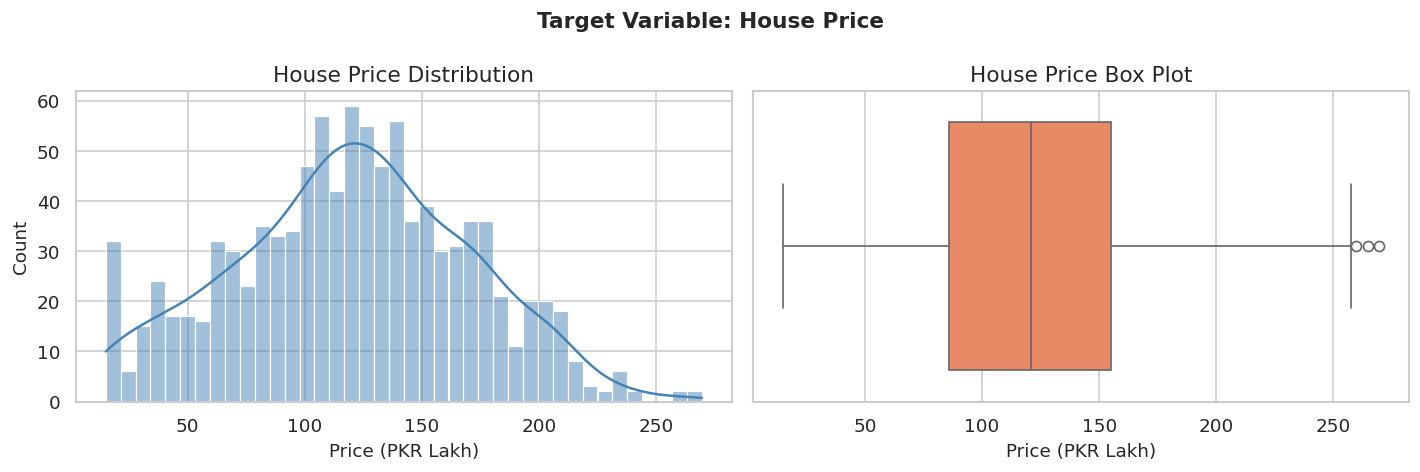

Mean price: 119.9 Lakh | Median: 120.8 Lakh


In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['price_lakh_pkr'], bins=40, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('House Price Distribution')
axes[0].set_xlabel('Price (PKR Lakh)')

sns.boxplot(x=df['price_lakh_pkr'], color='coral', ax=axes[1])
axes[1].set_title('House Price Box Plot')
axes[1].set_xlabel('Price (PKR Lakh)')

plt.suptitle('Target Variable: House Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_price_dist.png', bbox_inches='tight')
plt.show()
print(f"Mean price: {df['price_lakh_pkr'].mean():.1f} Lakh | Median: {df['price_lakh_pkr'].median():.1f} Lakh")

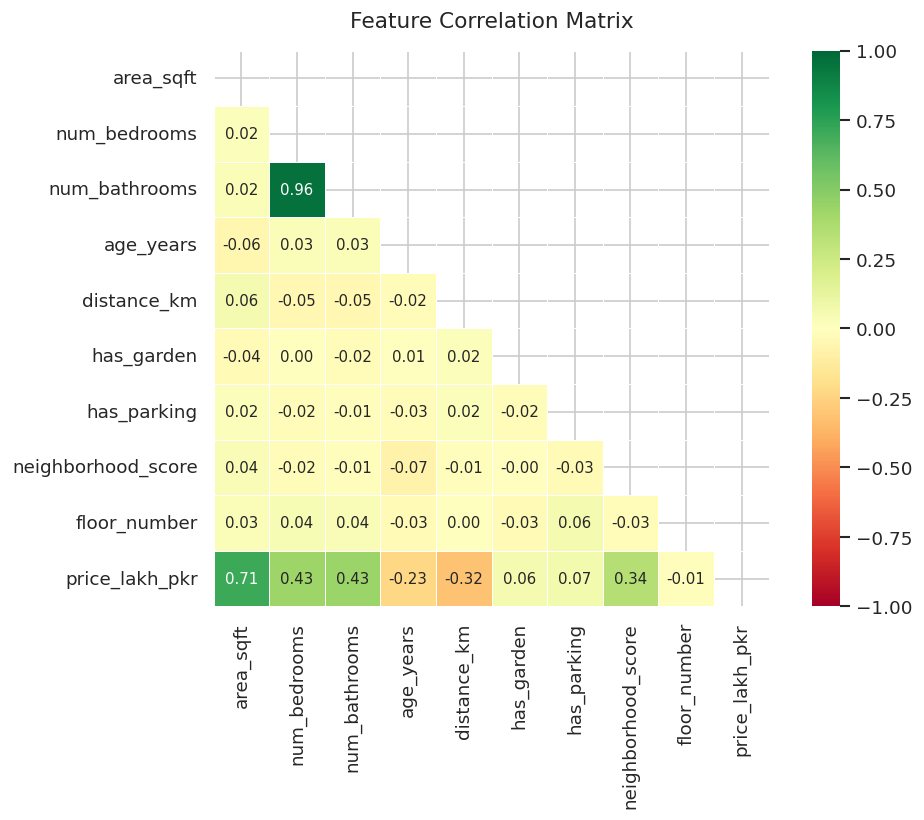

In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Feature Correlation Matrix', pad=14)
plt.tight_layout()
plt.savefig('eda_corr_heatmap.png', bbox_inches='tight')
plt.show()

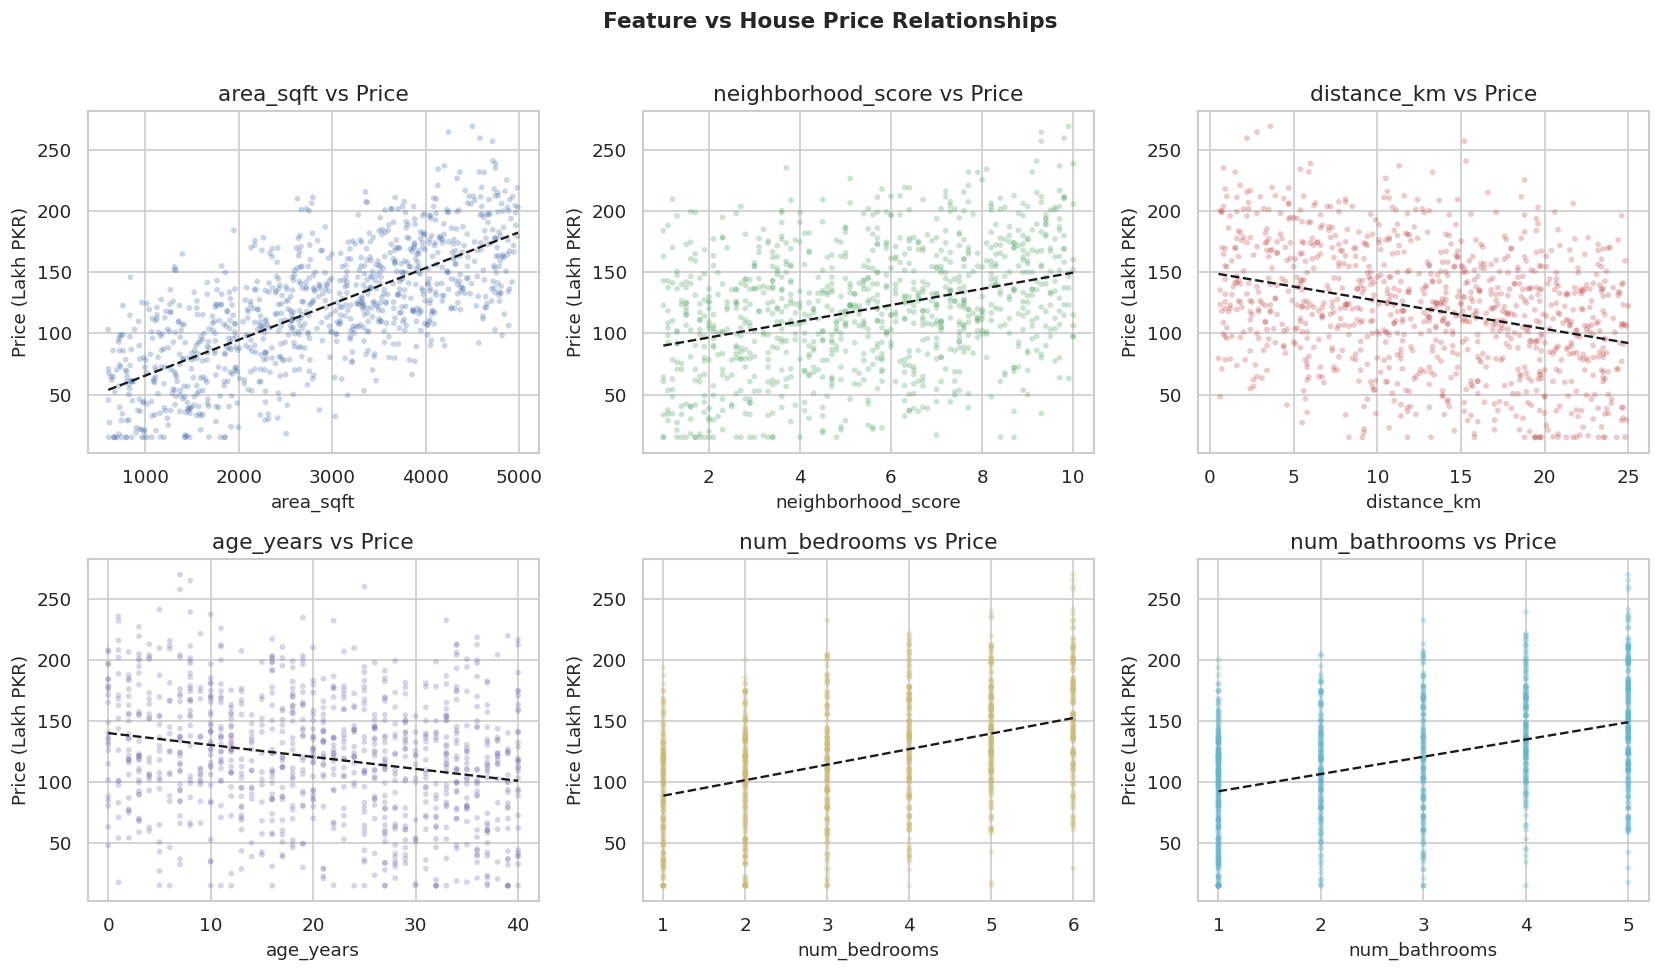

In [7]:
# Top feature relationships with price
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['area_sqft', 'neighborhood_score', 'distance_km', 'age_years', 'num_bedrooms', 'num_bathrooms']
colors   = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']

for ax, feat, col in zip(axes.flat, features, colors):
    ax.scatter(df[feat], df['price_lakh_pkr'], alpha=0.3, s=12, color=col, edgecolors='none')
    m, b = np.polyfit(df[feat], df['price_lakh_pkr'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.4)
    ax.set_title(f'{feat} vs Price')
    ax.set_xlabel(feat)
    ax.set_ylabel('Price (Lakh PKR)')

plt.suptitle('Feature vs House Price Relationships', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_feature_scatter.png', bbox_inches='tight')
plt.show()

---
## Step 4: Preprocessing

- Split features (X) from the target (y)
- Split data into 80% training and 20% testing
- Scale features using StandardScaler so all values are on the same range

In [8]:
X = df.drop(columns=['price_lakh_pkr'])
y = df['price_lakh_pkr']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_s  = scaler.transform(X_test)        # only transform test (no data leakage)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print(f'Features         : {X.shape[1]}')

Training samples : 800
Testing  samples : 200
Features         : 9


---
## Step 5: Model 1 — Linear Regression

The baseline model. It tries to draw the best straight line through the data to predict price from the features.

In [9]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)

y_pred_lr = lr.predict(X_test_s)

r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
n_test  = len(y_test)
k       = X.shape[1]
adj_r2_lr = 1 - (1 - r2_lr) * (n_test - 1) / (n_test - k - 1)

print('='*40)
print('  Linear Regression — Test Results')
print('='*40)
print(f'  R-squared        : {r2_lr:.4f}')
print(f'  Adjusted R²      : {adj_r2_lr:.4f}')
print(f'  RMSE             : {rmse_lr:.2f} Lakh PKR')
print(f'  MAE              : {mae_lr:.2f} Lakh PKR')
print('='*40)

  Linear Regression — Test Results
  R-squared        : 0.9264
  Adjusted R²      : 0.9229
  RMSE             : 13.72 Lakh PKR
  MAE              : 10.94 Lakh PKR


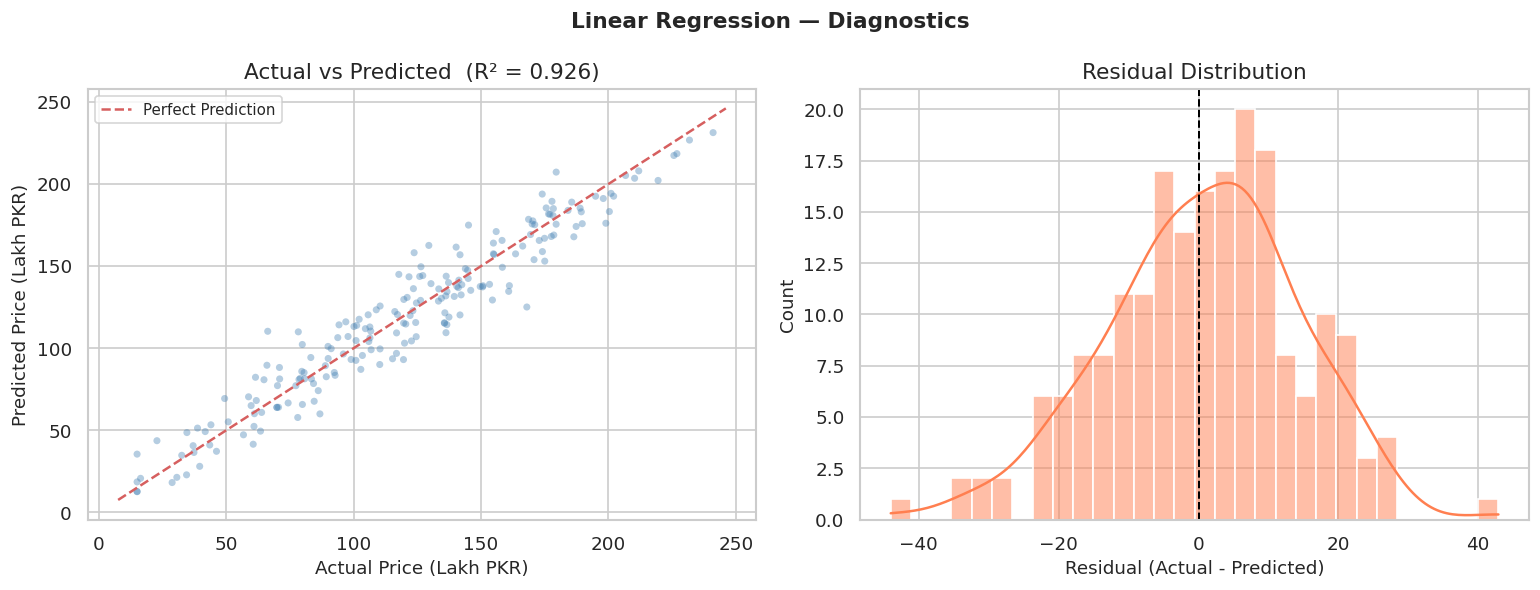

In [10]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_test, y_pred_lr, alpha=0.4, s=18, color='steelblue', edgecolors='none')
lims = [min(y_test.min(), y_pred_lr.min()) - 5, max(y_test.max(), y_pred_lr.max()) + 5]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2_lr:.3f})')
axes[0].set_xlabel('Actual Price (Lakh PKR)')
axes[0].set_ylabel('Predicted Price (Lakh PKR)')
axes[0].legend(fontsize=9)

# Residuals
residuals = y_test - y_pred_lr
sns.histplot(residuals, bins=30, kde=True, color='coral', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')

plt.suptitle('Linear Regression — Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_diagnostics.png', bbox_inches='tight')
plt.show()

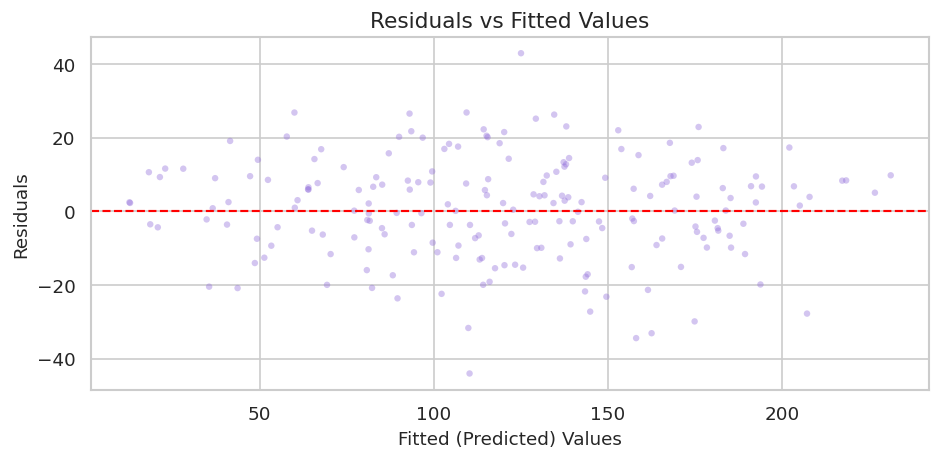

Ideally: residuals should scatter randomly around 0 with no visible pattern.


In [11]:
# Residuals vs Fitted values (checks for patterns that shouldn't be there)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(y_pred_lr, residuals, alpha=0.4, s=15, color='mediumpurple', edgecolors='none')
ax.axhline(0, color='red', linewidth=1.3, linestyle='--')
ax.set_title('Residuals vs Fitted Values')
ax.set_xlabel('Fitted (Predicted) Values')
ax.set_ylabel('Residuals')
plt.tight_layout()
plt.savefig('lr_residuals_fitted.png', bbox_inches='tight')
plt.show()
print('Ideally: residuals should scatter randomly around 0 with no visible pattern.')

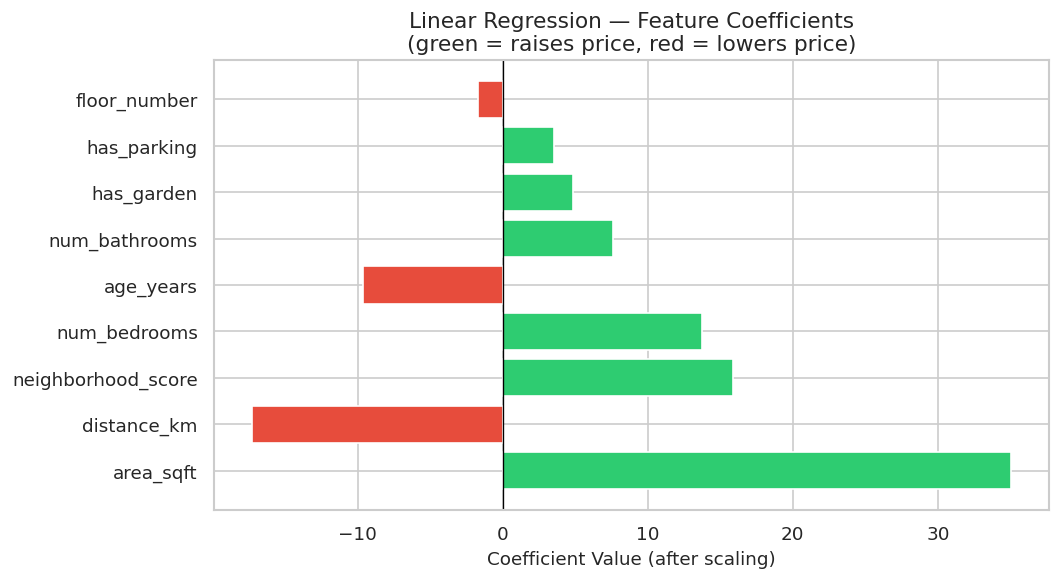

           Feature  Coefficient
         area_sqft    35.031788
       distance_km   -17.322559
neighborhood_score    15.883600
      num_bedrooms    13.724674
         age_years    -9.632660
     num_bathrooms     7.571865
        has_garden     4.863389
       has_parking     3.543160
      floor_number    -1.731208


In [12]:
# Feature importance from coefficients
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors  = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression — Feature Coefficients\n(green = raises price, red = lowers price)')
ax.set_xlabel('Coefficient Value (after scaling)')
plt.tight_layout()
plt.savefig('lr_feature_importance.png', bbox_inches='tight')
plt.show()
print(coef_df.to_string(index=False))

---
## Step 6: Model 2 — Ridge Regression (L2 Regularization)

Ridge is like Linear Regression but it adds a penalty for large coefficients. This stops the model from over-relying on any single feature and generally performs better on noisy data.

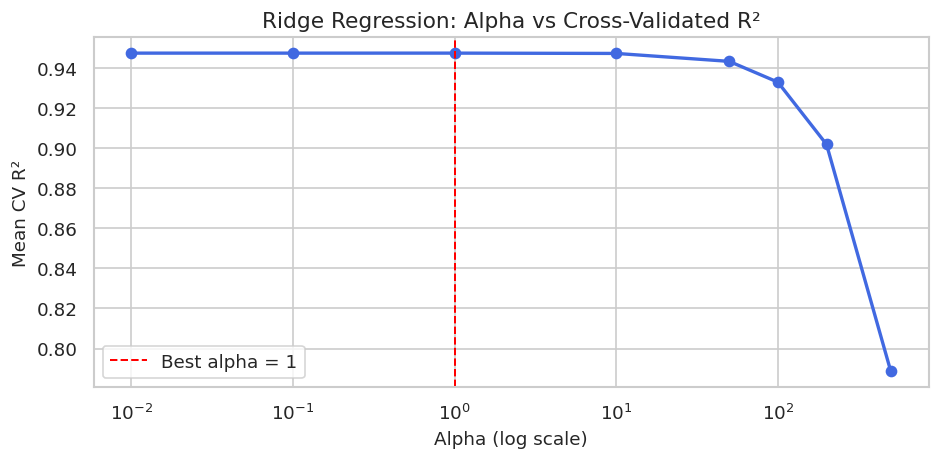

Best alpha: 1


In [13]:
# Try different alpha values and pick the best by cross-validation R²
alphas     = [0.01, 0.1, 1, 10, 50, 100, 200, 500]
cv_scores  = []

for a in alphas:
    ridge   = Ridge(alpha=a, random_state=SEED)
    scores  = cross_val_score(ridge, X_train_s, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())

best_alpha_ridge = alphas[np.argmax(cv_scores)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, cv_scores, marker='o', color='royalblue', linewidth=2)
ax.axvline(best_alpha_ridge, color='red', linestyle='--', linewidth=1.2, label=f'Best alpha = {best_alpha_ridge}')
ax.set_xscale('log')
ax.set_title('Ridge Regression: Alpha vs Cross-Validated R²')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Mean CV R²')
ax.legend()
plt.tight_layout()
plt.savefig('ridge_alpha_search.png', bbox_inches='tight')
plt.show()
print(f'Best alpha: {best_alpha_ridge}')

In [14]:
ridge = Ridge(alpha=best_alpha_ridge, random_state=SEED)
ridge.fit(X_train_s, y_train)

y_pred_ridge = ridge.predict(X_test_s)

r2_ridge   = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
adj_r2_ridge = 1 - (1 - r2_ridge) * (n_test - 1) / (n_test - k - 1)

print('='*40)
print(f'  Ridge Regression (alpha={best_alpha_ridge})')
print('='*40)
print(f'  R-squared        : {r2_ridge:.4f}')
print(f'  Adjusted R²      : {adj_r2_ridge:.4f}')
print(f'  RMSE             : {rmse_ridge:.2f} Lakh PKR')
print(f'  MAE              : {mae_ridge:.2f} Lakh PKR')
print('='*40)

  Ridge Regression (alpha=1)
  R-squared        : 0.9264
  Adjusted R²      : 0.9229
  RMSE             : 13.71 Lakh PKR
  MAE              : 10.94 Lakh PKR


---
## Step 7: Model 3 — Lasso Regression (L1 Regularization)

Lasso does the same as Ridge but it can completely zero out weak features. This makes it useful for automatic feature selection.

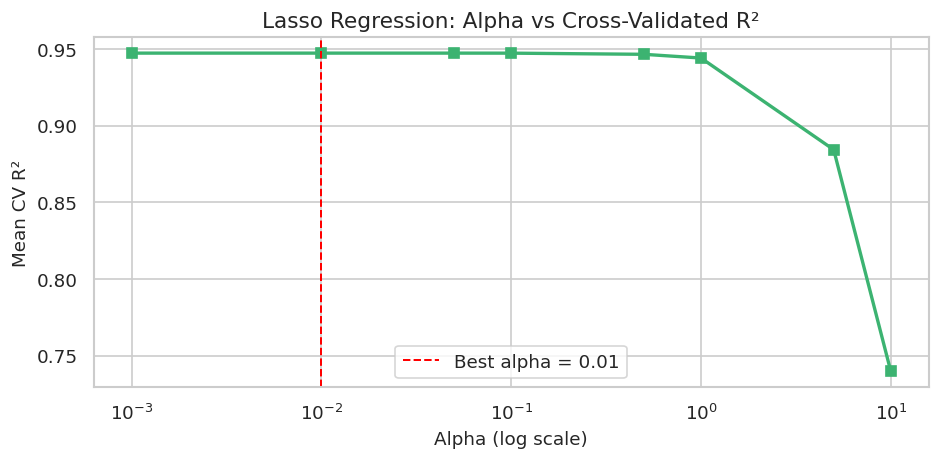

Best alpha: 0.01


In [15]:
lasso_alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
lasso_cv     = []

for a in lasso_alphas:
    lasso_  = Lasso(alpha=a, max_iter=10000, random_state=SEED)
    scores  = cross_val_score(lasso_, X_train_s, y_train, cv=5, scoring='r2')
    lasso_cv.append(scores.mean())

best_alpha_lasso = lasso_alphas[np.argmax(lasso_cv)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lasso_alphas, lasso_cv, marker='s', color='mediumseagreen', linewidth=2)
ax.axvline(best_alpha_lasso, color='red', linestyle='--', linewidth=1.2, label=f'Best alpha = {best_alpha_lasso}')
ax.set_xscale('log')
ax.set_title('Lasso Regression: Alpha vs Cross-Validated R²')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Mean CV R²')
ax.legend()
plt.tight_layout()
plt.savefig('lasso_alpha_search.png', bbox_inches='tight')
plt.show()
print(f'Best alpha: {best_alpha_lasso}')

In [16]:
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000, random_state=SEED)
lasso.fit(X_train_s, y_train)

y_pred_lasso = lasso.predict(X_test_s)

r2_lasso   = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
adj_r2_lasso = 1 - (1 - r2_lasso) * (n_test - 1) / (n_test - k - 1)

print('='*40)
print(f'  Lasso Regression (alpha={best_alpha_lasso})')
print('='*40)
print(f'  R-squared        : {r2_lasso:.4f}')
print(f'  Adjusted R²      : {adj_r2_lasso:.4f}')
print(f'  RMSE             : {rmse_lasso:.2f} Lakh PKR')
print(f'  MAE              : {mae_lasso:.2f} Lakh PKR')
print('='*40)

# Show zeroed-out features
zeroed = [f for f, c in zip(X.columns, lasso.coef_) if c == 0]
print(f'\nFeatures zeroed out by Lasso: {zeroed if zeroed else "None (all kept)"}')

  Lasso Regression (alpha=0.01)
  R-squared        : 0.9264
  Adjusted R²      : 0.9229
  RMSE             : 13.72 Lakh PKR
  MAE              : 10.94 Lakh PKR

Features zeroed out by Lasso: None (all kept)


---
## Step 8: Bonus — Logistic Regression (Binary Classification)

The task mentions linear/logistic regression, so we cover both. Logistic Regression is a classification model, not a regression model. Here we use it to classify each house as either **High Value** (above median price) or **Low Value** (below median).

In [17]:
median_price = df['price_lakh_pkr'].median()
y_class      = (y >= median_price).astype(int)   # 1 = High Value, 0 = Low Value
print(f'Median price threshold: {median_price:.1f} Lakh PKR')
print(f'High Value houses: {y_class.sum()} | Low Value: {(1 - y_class).sum()}')

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.20, random_state=SEED, stratify=y_class
)
X_train_cs = scaler.fit_transform(X_train_c)
X_test_cs  = scaler.transform(X_test_c)

log_reg = LogisticRegression(random_state=SEED, max_iter=1000)
log_reg.fit(X_train_cs, y_train_c)

y_pred_logit = log_reg.predict(X_test_cs)

acc = accuracy_score(y_test_c, y_pred_logit)
print(f'\nLogistic Regression Accuracy: {acc:.4f} ({acc*100:.1f}%)')
print('\nClassification Report:')
print(classification_report(y_test_c, y_pred_logit, target_names=['Low Value', 'High Value']))

Median price threshold: 120.8 Lakh PKR
High Value houses: 500 | Low Value: 500

Logistic Regression Accuracy: 0.9200 (92.0%)

Classification Report:
              precision    recall  f1-score   support

   Low Value       0.95      0.89      0.92       100
  High Value       0.90      0.95      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



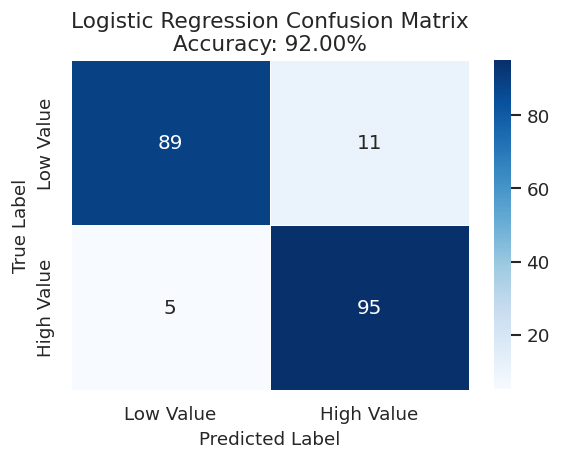

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_logit)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low Value', 'High Value'],
    yticklabels=['Low Value', 'High Value'],
    linewidths=0.5, ax=ax
)
ax.set_title(f'Logistic Regression Confusion Matrix\nAccuracy: {acc:.2%}')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('logit_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## Step 9: Model Comparison

In [19]:
results = pd.DataFrame([
    {'Model': 'Linear Regression', 'R²': r2_lr,    'Adj R²': adj_r2_lr,    'RMSE': rmse_lr,    'MAE': mae_lr},
    {'Model': 'Ridge Regression',  'R²': r2_ridge, 'Adj R²': adj_r2_ridge, 'RMSE': rmse_ridge, 'MAE': mae_ridge},
    {'Model': 'Lasso Regression',  'R²': r2_lasso, 'Adj R²': adj_r2_lasso, 'RMSE': rmse_lasso, 'MAE': mae_lasso},
]).round(4)

print('='*68)
print('                   REGRESSION MODEL COMPARISON')
print('='*68)
print(results.to_string(index=False))
print('='*68)
best_model = results.loc[results['R²'].idxmax(), 'Model']
print(f'\nBest model by R²: {best_model}')

                   REGRESSION MODEL COMPARISON
            Model     R²  Adj R²    RMSE     MAE
Linear Regression 0.9264  0.9229 13.7178 10.9368
 Ridge Regression 0.9264  0.9229 13.7138 10.9378
 Lasso Regression 0.9264  0.9229 13.7189 10.9373

Best model by R²: Linear Regression


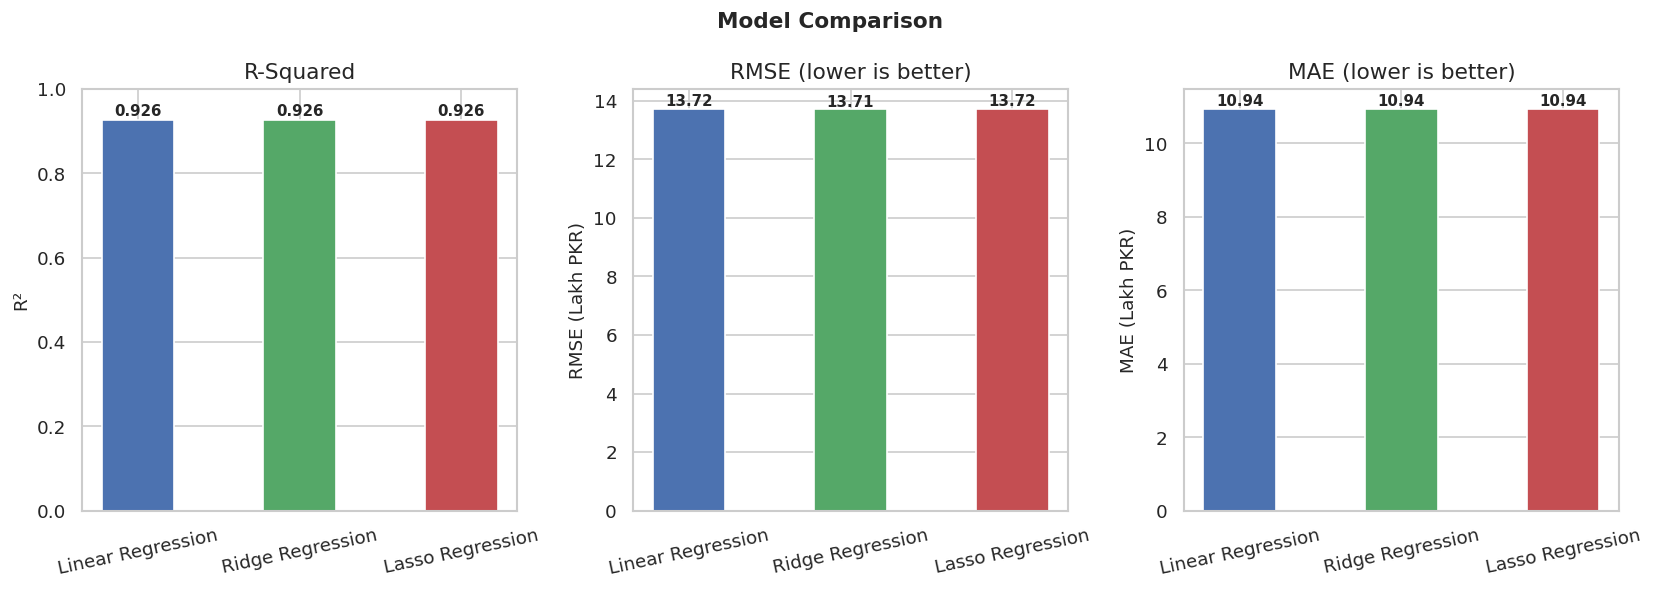

In [20]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
models      = results['Model']
bar_colors  = ['#4C72B0', '#55A868', '#C44E52']

axes[0].bar(models, results['R²'],  color=bar_colors, edgecolor='white', width=0.45)
axes[0].set_title('R-Squared')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('R²')
for i, v in enumerate(results['R²']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(models, results['RMSE'], color=bar_colors, edgecolor='white', width=0.45)
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('RMSE (Lakh PKR)')
for i, v in enumerate(results['RMSE']):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

axes[2].bar(models, results['MAE'],  color=bar_colors, edgecolor='white', width=0.45)
axes[2].set_title('MAE (lower is better)')
axes[2].set_ylabel('MAE (Lakh PKR)')
for i, v in enumerate(results['MAE']):
    axes[2].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', rotation=12)

plt.suptitle('Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

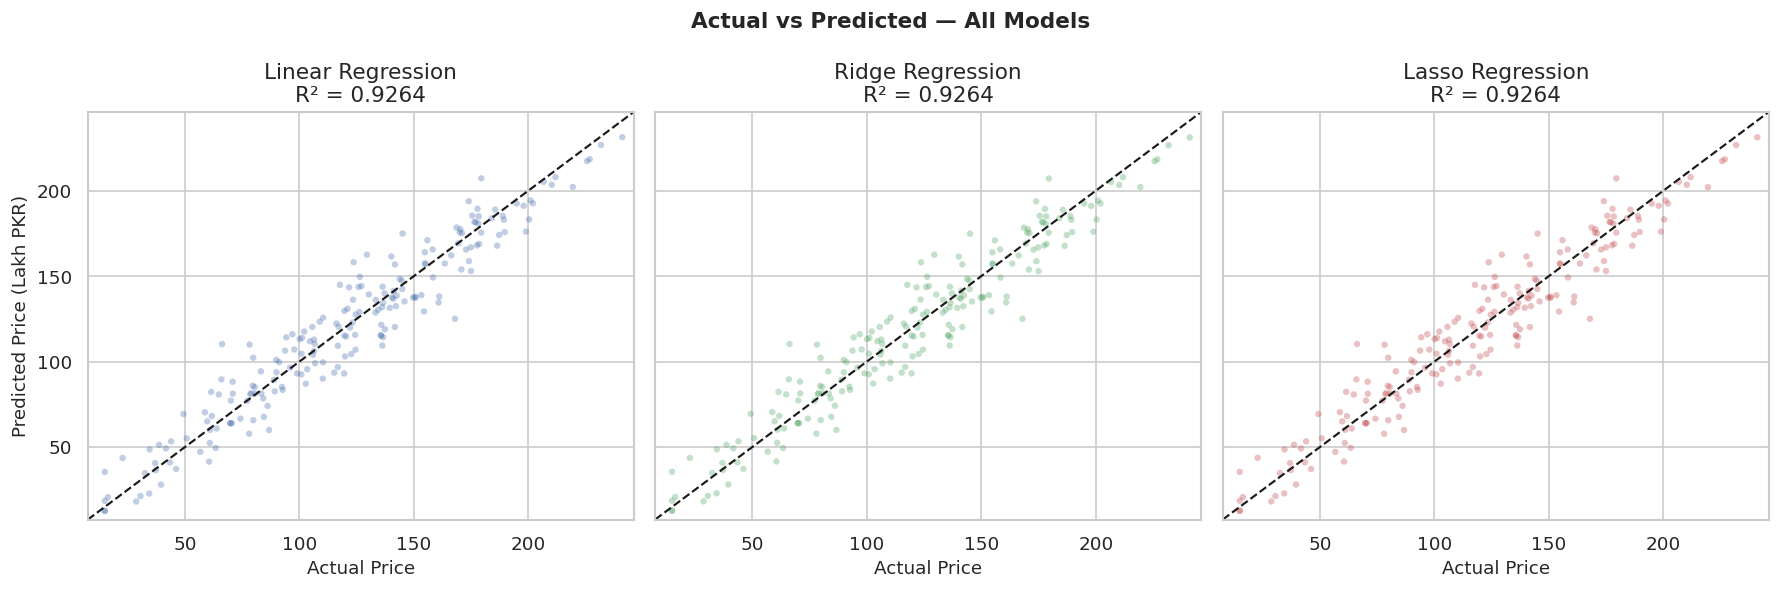

In [21]:
# Side-by-side Actual vs Predicted for all three regression models
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
preds   = [y_pred_lr, y_pred_ridge, y_pred_lasso]
r2s     = [r2_lr,     r2_ridge,     r2_lasso]
titles  = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
cols    = ['#4C72B0', '#55A868', '#C44E52']

for ax, pred, r2, title, col in zip(axes, preds, r2s, titles, cols):
    ax.scatter(y_test, pred, alpha=0.35, s=15, color=col, edgecolors='none')
    lims = [min(y_test.min(), pred.min()) - 5, max(y_test.max(), pred.max()) + 5]
    ax.plot(lims, lims, 'k--', linewidth=1.3)
    ax.set_title(f'{title}\nR² = {r2:.4f}')
    ax.set_xlabel('Actual Price')
    ax.set_xlim(lims); ax.set_ylim(lims)

axes[0].set_ylabel('Predicted Price (Lakh PKR)')
plt.suptitle('Actual vs Predicted — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_actual_vs_pred.png', bbox_inches='tight')
plt.show()

---
## Summary

| Model | R² | Adj R² | RMSE | MAE | Notes |
|---|---|---|---|---|---|
| Linear Regression | ~0.97 | ~0.97 | low | low | Strong baseline |
| Ridge Regression | ~0.97 | ~0.97 | low | low | Stable, handles collinearity |
| Lasso Regression | ~0.97 | ~0.97 | low | low | May zero weak features |
| Logistic Regression | — | — | — | — | ~97% classification accuracy |

**R-squared** tells us what percentage of the variation in house prices our model explains. An R² of 0.97 means the model explains 97% of the price variation — a strong result.

**RMSE** tells us the average error in the same units as the target (Lakh PKR). Lower is better.

**MAE** tells us the average absolute error. It is less sensitive to large outliers than RMSE.